# 0630 TeaLeaf CG calc_w filtering plots

Derived from `plot_entry_filt.0617.ipynb`; explicit per-kernel run roots, no latest-run selection.


In [1]:
from pathlib import Path
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
DATE_BASE = "20260630"
HOST_ORDER = ["cgnr6760pn2", "camd9554n1", "c920bn3"]
SHUFFLE_SELECT = "shuffle2"
SHUFFLE_BY_HOST = {'cgnr6760pn2': 'shuffle1', 'camd9554n1': 'shuffle1', 'c920bn3': 'shuffle2'}  # per-host best shuffle (fewest negative-reduction sizes, then max mean reduction_pct)
TARGET_KERNEL = "tl_f90_cg_calc_w"
PATH_CONFIG = Path('/astrum/home/hpchzy/code/TacVar/stencil/kernel_full_paths.0630.json')

# 0630 mid-grain full runs: per host/kernel paths are patched into PATH_CONFIG as soon as each node finishes.
def load_run_root_overrides():
    if not PATH_CONFIG.exists():
        raise FileNotFoundError(f"missing path config: {PATH_CONFIG}")
    cfg = json.loads(PATH_CONFIG.read_text())
    if TARGET_KERNEL not in cfg:
        raise KeyError(f"missing TARGET_KERNEL={TARGET_KERNEL} in {PATH_CONFIG}")
    missing = [host for host in HOST_ORDER if host not in cfg[TARGET_KERNEL]]
    if missing:
        raise RuntimeError(f"missing hosts for TARGET_KERNEL={TARGET_KERNEL} in {PATH_CONFIG}: {missing}")
    roots = {}
    for host in HOST_ORDER:
        item = cfg[TARGET_KERNEL][host]
        date_base = item['date_base']
        output_root = item['output_root']
        run_id = item['run_id']
        # shuffle = item.get('shuffle', SHUFFLE_SELECT)
        shuffle = SHUFFLE_BY_HOST.get(host, SHUFFLE_SELECT) or item.get('shuffle', SHUFFLE_SELECT)
        roots[host] = Path(f"/astrum/home/hpchzy/code/data/{date_base}/{host}/{output_root}/{run_id}/{shuffle}")
    return roots

RUN_ROOT_OVERRIDES = load_run_root_overrides()


def latest_run_root(host, shuffle_select=SHUFFLE_SELECT):
    if host not in RUN_ROOT_OVERRIDES:
        raise KeyError(f"missing explicit RUN_ROOT override for {host}")
    root = RUN_ROOT_OVERRIDES[host]
    if not root.exists():
        raise FileNotFoundError(f"missing data folder: {root}")
    return root

RUN_ROOTS = [latest_run_root(host, SHUFFLE_SELECT).parent for host in HOST_ORDER]
DATA_FOLDERS = [latest_run_root(host, SHUFFLE_SELECT) for host in HOST_ORDER]
SHUFFLE_LABEL = "_".join(f"{host}-{Path(root).name}" for host, root in zip(HOST_ORDER, DATA_FOLDERS))

QUANTILE_DROP = 1.0
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_tl_f90_cg_calc_w_dsub')

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#e377c2',
    'cntvcto': '#e377c2',
}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCTO',
}

KERNEL_LABELS = {
    'jacobi2d5p': '2D 5-Point Jacobi Stencil',
    'gs2d5p': '2D 5-Point Gauss-Seidel',
    'tl_f90_cg_calc_w': 'TeaLeaf CG calc_w',
    'stream_triad': 'STREAM Triad',
    'openblas_gemm': 'OpenBLAS-style GEMM',
    'openblas_gemv': 'OpenBLAS-style GEMV',
    'openblas_dot': 'OpenBLAS-style DOT',
    'openblas_axpy': 'OpenBLAS-style AXPY',
    'hpcg_spmv': 'HPCG SpMV',
    'npb_ft_fft': 'NPB-FT FFT',
    'npb_ep': 'NPB-EP',
}

HOST_LABELS = {
    "cgnr6760pn2": "Intel Xeon 6760P",
    "camd9554n1": "AMD EPYC 9554",
    "camd9554n2": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}

for root in DATA_FOLDERS:
    print(root)
print("target_kernel:", TARGET_KERNEL)
print("host_order:", HOST_ORDER)
print("path_config:", PATH_CONFIG)
print("shuffle_label:", SHUFFLE_LABEL)


/astrum/home/hpchzy/code/data/20260630/cgnr6760pn2/output_tl_f90_cg_calc_w_filt_dsub/20260630-full-tl-f90-cg-calc-w-dsub/shuffle2
/astrum/home/hpchzy/code/data/20260630/camd9554n1/output_tl_f90_cg_calc_w_filt_dsub/20260630-full-tl-f90-cg-calc-w-dsub/shuffle2
/astrum/home/hpchzy/code/data/20260630/c920bn3/output_tl_f90_cg_calc_w_filt_dsub/20260630-full-tl-f90-cg-calc-w-dsub/shuffle2
target_kernel: tl_f90_cg_calc_w
host_order: ['cgnr6760pn2', 'camd9554n1', 'c920bn3']
path_config: /astrum/home/hpchzy/code/TacVar/stencil/kernel_full_paths.0630.json
shuffle_label: cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2


In [3]:
def parse_filt_dir(path):
    m = re.match(r'(?P<prefix>.+)_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<nsampRatio>[\d.]+)_nsamp(?P<nsamp>\d+)_filt$', path.name)
    if not m:
        return None
    d = m.groupdict()
    prefix = d.pop('prefix')
    kernel = None
    timer = None
    for candidate in sorted(TIMER_LABELS, key=len, reverse=True):
        suffix = f'_{candidate}'
        if prefix.endswith(suffix):
            kernel = prefix[:-len(suffix)]
            timer = candidate
            break
    if not kernel or not timer:
        return None
    d['kernel'] = kernel
    d['timer'] = timer
    d['np'] = int(d['np'])
    d['size'] = int(d['size'])
    d['nsamp'] = int(d['nsamp'])
    d['nsampRatio'] = float(d['nsampRatio'])
    return d


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cntvct', 'cntvcto', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    return df['ns'].to_numpy()


def read_tr(tr_hist_file):
    """Read tr_hist.csv as piecewise-linear CDF.

    Format: (left_edge, prob) per row; bin [t_i, t_{i+1}) has probability prob_i;
    last row is sentinel with prob=0 (right boundary).
    Returns df with cdf[i] = cumulative probability at LEFT edge of bin i,
    so plotting ns vs cdf gives a diagonal piecewise-linear CDF (not step function).
    """
    df = pd.read_csv(tr_hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df.sort_values('ns', inplace=True)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    cs = df['prob'].cumsum()
    # Keep bins whose LEFT edge starts below QUANTILE_DROP, plus one right-boundary row.
    left_cdf = cs.shift(1, fill_value=0.0)
    keep = left_cdf < QUANTILE_DROP
    if keep.any():
        iloc_last = df.index.get_loc(keep[keep].index[-1])
        if iloc_last + 1 < len(df):
            keep.iloc[iloc_last + 1] = True
    df = df[keep].copy()
    # cdf[i] = CDF at left edge of bin i = sum of probs of all PREVIOUS bins
    df['cdf'] = df['prob'].cumsum().shift(1, fill_value=0.0)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)

entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
print(f'entries before filter: {len(entries)}')
entries = entries[entries['kernel'] == TARGET_KERNEL].copy()
entries = entries[(entries['timer'] != 'tsc_native') & (entries['timer'] != 'cntvct')]
if entries.empty:
    raise RuntimeError(f'No filt entries for TARGET_KERNEL={TARGET_KERNEL} in {DATA_FOLDERS}')
print(f'entries after {TARGET_KERNEL} filter: {len(entries)}')
entries.sort_values(['host', 'kernel', 'np', 'size', 'timer']).head(20)


entries before filter: 90
entries after tl_f90_cg_calc_w filter: 90


,np,size,nsampRatio,nsamp,kernel,timer,host,data_folder,shuffle,filt_dir,tm_file,tr_hist_file
65,64,64,0.5,188,tl_f90_cg_calc_w,cgt,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
71,64,64,0.5,173,tl_f90_cg_calc_w,cntvcto,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
77,64,64,0.5,391,tl_f90_cg_calc_w,papi,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
83,64,64,0.5,391,tl_f90_cg_calc_w,papix6,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
89,64,64,0.5,188,tl_f90_cg_calc_w,wtime,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
61,64,128,0.5,333,tl_f90_cg_calc_w,cgt,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
67,64,128,0.5,318,tl_f90_cg_calc_w,cntvcto,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
73,64,128,0.5,536,tl_f90_cg_calc_w,papi,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
79,64,128,0.5,536,tl_f90_cg_calc_w,papix6,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
85,64,128,0.5,333,tl_f90_cg_calc_w,wtime,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...


# ER/EP/Wasserstein

In [4]:
from scipy.stats import wasserstein_distance


def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def clean_hist_for_wd(hist_file, ns_col='ns', pr_col='pr'):
    df = pd.read_csv(hist_file, header=None, names=[ns_col, pr_col])
    df[ns_col] = pd.to_numeric(df[ns_col], errors='coerce')
    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')
    df = df[np.isfinite(df[ns_col]) & np.isfinite(df[pr_col])].copy()
    df = df[df[pr_col] > 0]
    if df.empty or df[pr_col].sum() <= 0:
        return None
    return df


def wd_to_min(hist_file):
    df = clean_hist_for_wd(hist_file)
    if df is None:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['pr'].to_numpy(dtype=float)
    return wasserstein_distance(ns, np.array([ns.min()]), pr, np.array([1.0]))


def read_hist_for_sampling(hist_file):
    """Read (lb, pr) histogram into (lb, rb, pr) DataFrame for quantile sampling."""
    try:
        tmp = pd.read_csv(hist_file, header=None, names=['lb', 'pr'])
    except Exception:
        return None
    tmp['lb'] = pd.to_numeric(tmp['lb'], errors='coerce')
    tmp['pr'] = pd.to_numeric(tmp['pr'], errors='coerce').fillna(0.0)
    tmp = tmp.dropna(subset=['lb']).reset_index(drop=True)
    m = ~np.isclose(tmp['pr'], 0)
    if not m.any():
        return None
    last_nz = int(np.where(m)[0][-1])
    if last_nz + 1 >= len(tmp):
        return None
    tmp = tmp.iloc[:last_nz + 2].copy()
    tmp['rb'] = tmp['lb'].shift(-1)
    tmp['lb'] = tmp['lb'].astype(np.float64)
    tmp = tmp[['lb', 'rb', 'pr']].iloc[:-1].dropna()
    return tmp if not tmp.empty else None


def sample_from_bins_quantile(tmp_df, n=1000):
    lb = tmp_df['lb'].to_numpy()
    rb = tmp_df['rb'].to_numpy()
    pr = tmp_df['pr'].to_numpy()
    pr = pr / pr.sum()
    p0 = np.r_[0, np.cumsum(pr)]
    q = (np.arange(n) + 0.5) / n
    idx = np.searchsorted(p0[1:], q, side='right')
    local_t = (q - p0[idx]) / pr[idx]
    return lb[idx] + local_t * (rb[idx] - lb[idx])


SEQ_N = 1000

summary_rows = []
for idx, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    ep = read_float_file(filt_folder / 'ep.out')
    er = read_float_file(filt_folder / 'er.out')
    wd = read_float_file(filt_folder / 'wd.out')
    tm_wd = wd_to_min(filt_folder / 'tm_hist.csv')
    tr_wd = wd_to_min(filt_folder / 'tr_hist.csv')
    if not np.isfinite(tm_wd) or not np.isfinite(tr_wd):
        print(f"warning: invalid histogram for Wasserstein: {filt_folder.name} tm_wd={tm_wd} tr_wd={tr_wd}")
    _tr_h = read_hist_for_sampling(filt_folder / 'tr_hist.csv')
    _tm_h = read_hist_for_sampling(filt_folder / 'tm_hist.csv')
    tr_seq = sample_from_bins_quantile(_tr_h, SEQ_N) if _tr_h is not None else None
    tm_seq = sample_from_bins_quantile(_tm_h, SEQ_N) if _tm_h is not None else None
    summary_rows.append({**row.to_dict(), 'ep': ep, 'er': er, 'wd': wd, 'tm_wd': tm_wd, 'tr_wd': tr_wd, 'tr_seq': tr_seq, 'tm_seq': tm_seq})

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df.sort_values(['host', 'kernel', 'np', 'size', 'timer'], inplace=True)

df = df[df['kernel'] == TARGET_KERNEL].copy()
if df.empty:
    raise RuntimeError(f'No summary rows for TARGET_KERNEL={TARGET_KERNEL}')

df[['host', 'kernel', 'timer', 'np', 'size', 'ep', 'er', 'wd', 'tm_wd', 'tr_wd']].head(20)  # tr_seq/tm_seq stored as object columns


,host,kernel,timer,np,size,ep,er,wd,tm_wd,tr_wd
65,c920bn3,tl_f90_cg_calc_w,cgt,64,64,0.056508,0.045804,5.948744,9.323757,9.323760
71,c920bn3,tl_f90_cg_calc_w,cntvcto,64,64,0.222411,0.057379,7.010050,0.000000,0.000000
77,c920bn3,tl_f90_cg_calc_w,papi,64,64,0.006256,0.035343,9.650251,21.171691,21.171671
83,c920bn3,tl_f90_cg_calc_w,papix6,64,64,0.001545,0.022658,6.157789,19.589816,19.589790
89,c920bn3,tl_f90_cg_calc_w,wtime,64,64,0.000000,0.043265,5.631156,9.775639,6.267630
61,c920bn3,tl_f90_cg_calc_w,cgt,64,128,0.125183,0.025874,6.033166,13.287848,12.120340
67,c920bn3,tl_f90_cg_calc_w,cntvcto,64,128,0.011381,0.023935,5.313568,4.146614,2.716860
73,c920bn3,tl_f90_cg_calc_w,papi,64,128,0.000012,0.020757,7.809045,24.964305,24.964300
79,c920bn3,tl_f90_cg_calc_w,papix6,64,128,0.000112,0.027133,10.196985,24.335981,24.335940
85,c920bn3,tl_f90_cg_calc_w,wtime,64,128,0.136282,0.028509,6.640201,13.661511,12.749060


In [5]:
# Size-level cross-timer divergence table, printed before plotting.
# Reference timers follow the 0630 policy: x86 -> tsc, ARM -> cntvcto.
from scipy.stats import wasserstein_distance

REF_TIMER_BY_HOST = {'cgnr6760pn2': 'tsc', 'camd9554n1': 'tsc', 'c920bn3': 'cntvcto'}


def _wd_seq(a, b):
    if a is None or b is None:
        return np.nan
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return wasserstein_distance(a, b) if (a.size and b.size) else np.nan


def divergence_table(src, group_keys):
    """Size-level TM/TR cross-timer divergence and TM->TR reduction.

    For each group, compute WD(non-ref timer, ref timer) for TM and TR,
    then aggregate non-ref timers by sum/mean. Percent columns normalize the
    mean divergence by the reference TM mean, matching the existing figure scale.
    """
    rows = []
    for gv, g in src.groupby(group_keys, sort=True):
        gd = dict(zip(group_keys, gv if isinstance(gv, tuple) else (gv,)))
        ref_timer = REF_TIMER_BY_HOST.get(gd['host'])
        ref = g[g['timer'] == ref_timer]
        if ref.empty:
            continue
        ref = ref.iloc[0]
        ref_tm = np.asarray(ref['tm_seq'], dtype=float) if ref['tm_seq'] is not None else None
        ref_tr = np.asarray(ref['tr_seq'], dtype=float) if ref['tr_seq'] is not None else None
        base = float(np.mean(ref_tm)) if (ref_tm is not None and ref_tm.size) else np.nan
        tm_ds, tr_ds = [], []
        for _, r in g.iterrows():
            if r['timer'] == ref_timer:
                continue
            d_tm = _wd_seq(r['tm_seq'], ref_tm)
            d_tr = _wd_seq(r['tr_seq'], ref_tr)
            if np.isfinite(d_tm):
                tm_ds.append(float(d_tm))
            if np.isfinite(d_tr):
                tr_ds.append(float(d_tr))
        tm_sum = float(np.sum(tm_ds)) if tm_ds else np.nan
        tr_sum = float(np.sum(tr_ds)) if tr_ds else np.nan
        tm_mean = float(np.mean(tm_ds)) if tm_ds else np.nan
        tr_mean = float(np.mean(tr_ds)) if tr_ds else np.nan
        reduction = (tm_sum - tr_sum) / tm_sum if (np.isfinite(tm_sum) and tm_sum > 0) else np.nan
        if np.isfinite(base) and base > 0:
            tm_pct = 100.0 * tm_mean / base if np.isfinite(tm_mean) else np.nan
            tr_pct = 100.0 * tr_mean / base if np.isfinite(tr_mean) else np.nan
            d_before = tm_mean / base if np.isfinite(tm_mean) else np.nan
            d_after = tr_mean / base if np.isfinite(tr_mean) else np.nan
        else:
            tm_pct = tr_pct = d_before = d_after = np.nan
        rows.append({
            **gd,
            'ref_timer': ref_timer,
            'n_timer': len(tm_ds),
            'tm_div_sum_ns': tm_sum,
            'tr_div_sum_ns': tr_sum,
            'tm_div_mean_ns': tm_mean,
            'tr_div_mean_ns': tr_mean,
            'tm_div_pct_ref': tm_pct,
            'tr_div_pct_ref': tr_pct,
            'reduction': reduction,
            'reduction_pct': 100.0 * reduction if np.isfinite(reduction) else np.nan,
            # Compatibility with the existing WD/divergence figure cell.
            'd_before': d_before,
            'd_after': d_after,
        })
    cols = [
        'kernel', 'host', 'np', 'size', 'nsampRatio', 'ref_timer', 'n_timer',
        'tm_div_sum_ns', 'tr_div_sum_ns', 'tm_div_mean_ns', 'tr_div_mean_ns',
        'tm_div_pct_ref', 'tr_div_pct_ref', 'reduction', 'reduction_pct', 'd_before', 'd_after',
    ]
    return pd.DataFrame(rows).reindex(columns=cols)


div_size_df = divergence_table(df, ['kernel', 'host', 'np', 'size', 'nsampRatio'])
div_df = div_size_df.copy()

print(f'[SIZE DIVERGENCE] kernel={TARGET_KERNEL} {SHUFFLE_LABEL}')
_print_cols = [
    'kernel', 'host', 'np', 'size', 'nsampRatio', 'ref_timer', 'n_timer',
    'tm_div_sum_ns', 'tr_div_sum_ns', 'tm_div_mean_ns', 'tr_div_mean_ns',
    'tm_div_pct_ref', 'tr_div_pct_ref', 'reduction', 'reduction_pct',
]
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 220):
    print(div_size_df[_print_cols].sort_values(['kernel', 'host', 'np', 'size', 'nsampRatio']).to_string(index=False))

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    div_csv = OUT_DIR / f'{TARGET_KERNEL}_{SHUFFLE_LABEL}_size_divergence.csv'
    div_size_df[_print_cols].sort_values(['kernel', 'host', 'np', 'size', 'nsampRatio']).to_csv(div_csv, index=False)
    print(div_csv)


[SIZE DIVERGENCE] kernel=tl_f90_cg_calc_w cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2
          kernel        host  np  size  nsampRatio ref_timer  n_timer  tm_div_sum_ns  tr_div_sum_ns  tm_div_mean_ns  tr_div_mean_ns  tm_div_pct_ref  tr_div_pct_ref  reduction  reduction_pct
tl_f90_cg_calc_w     c920bn3  64    64         0.5   cntvcto        4     341.263023      40.368137       85.315756       10.092034       71.096463        8.410028   0.881710      88.170961
tl_f90_cg_calc_w     c920bn3  64   128         0.5   cntvcto        4     344.729329      20.802291       86.182332        5.200573       38.594935        2.328967   0.939656      93.965616
tl_f90_cg_calc_w     c920bn3  64   256         0.5   cntvcto        4     605.328170      91.789320      151.332043       22.947330       26.418933        4.006052   0.848364      84.836437
tl_f90_cg_calc_w     c920bn3  64   512         0.5   cntvcto        4    1351.472633     956.342927      337.868158      239.085732       12

In [6]:
# Generic cross-timer spread table: (max(timer median) - min(timer median)) / median(timer medians).
# This is intentionally separate from the Wasserstein div_size_df above.

def _finite_median(seq):
    arr = np.asarray(seq, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(np.median(arr)) if arr.size else np.nan


def generic_timer_spread_table(src, group_keys):
    rows = []
    for gv, g in src.groupby(group_keys, sort=True):
        gd = dict(zip(group_keys, gv if isinstance(gv, tuple) else (gv,)))
        timer_rows = []
        for _, r in g.iterrows():
            tm_med = _finite_median(r['tm_seq'])
            tr_med = _finite_median(r['tr_seq'])
            if np.isfinite(tm_med) and np.isfinite(tr_med):
                timer_rows.append({'timer': r['timer'], 'tm_median_ns': tm_med, 'tr_median_ns': tr_med})
        if len(timer_rows) < 2:
            continue
        td = pd.DataFrame(timer_rows)
        tm_vals = td['tm_median_ns'].to_numpy(dtype=float)
        tr_vals = td['tr_median_ns'].to_numpy(dtype=float)
        tm_center = float(np.median(tm_vals))
        tr_center = float(np.median(tr_vals))
        tm_spread = (float(np.max(tm_vals)) - float(np.min(tm_vals))) / tm_center if tm_center > 0 else np.nan
        tr_spread = (float(np.max(tr_vals)) - float(np.min(tr_vals))) / tr_center if tr_center > 0 else np.nan
        tm_min_idx = int(td['tm_median_ns'].idxmin())
        tm_max_idx = int(td['tm_median_ns'].idxmax())
        tr_min_idx = int(td['tr_median_ns'].idxmin())
        tr_max_idx = int(td['tr_median_ns'].idxmax())
        rows.append({
            **gd,
            'n_timer': int(len(td)),
            'tm_median_center_ns': tm_center,
            'tr_median_center_ns': tr_center,
            'tm_min_ns': float(np.min(tm_vals)),
            'tm_max_ns': float(np.max(tm_vals)),
            'tr_min_ns': float(np.min(tr_vals)),
            'tr_max_ns': float(np.max(tr_vals)),
            'tm_spread_pct': 100.0 * tm_spread if np.isfinite(tm_spread) else np.nan,
            'tr_spread_pct': 100.0 * tr_spread if np.isfinite(tr_spread) else np.nan,
            'spread_delta_pct': 100.0 * (tr_spread - tm_spread) if (np.isfinite(tm_spread) and np.isfinite(tr_spread)) else np.nan,
            'spread_reduction_pct': 100.0 * (tm_spread - tr_spread) / tm_spread if (np.isfinite(tm_spread) and tm_spread > 0 and np.isfinite(tr_spread)) else np.nan,
            'tm_min_timer': td.loc[tm_min_idx, 'timer'],
            'tm_max_timer': td.loc[tm_max_idx, 'timer'],
            'tr_min_timer': td.loc[tr_min_idx, 'timer'],
            'tr_max_timer': td.loc[tr_max_idx, 'timer'],
        })
    cols = [
        'kernel', 'host', 'np', 'size', 'nsampRatio', 'n_timer',
        'tm_median_center_ns', 'tr_median_center_ns',
        'tm_min_ns', 'tm_max_ns', 'tr_min_ns', 'tr_max_ns',
        'tm_spread_pct', 'tr_spread_pct', 'spread_delta_pct', 'spread_reduction_pct',
        'tm_min_timer', 'tm_max_timer', 'tr_min_timer', 'tr_max_timer',
    ]
    return pd.DataFrame(rows).reindex(columns=cols)


generic_spread_df = generic_timer_spread_table(df, ['kernel', 'host', 'np', 'size', 'nsampRatio'])
_generic_cols = [
    'kernel', 'host', 'np', 'size', 'nsampRatio', 'n_timer',
    'tm_spread_pct', 'tr_spread_pct', 'spread_delta_pct', 'spread_reduction_pct',
    'tm_min_timer', 'tm_max_timer', 'tr_min_timer', 'tr_max_timer',
]
print(f'[GENERIC TIMER SPREAD] kernel={TARGET_KERNEL} {SHUFFLE_LABEL}')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 220):
    print(generic_spread_df[_generic_cols].sort_values(['kernel', 'host', 'np', 'size', 'nsampRatio']).to_string(index=False))

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    generic_csv = OUT_DIR / f'{TARGET_KERNEL}_{SHUFFLE_LABEL}_generic_timer_spread.csv'
    generic_spread_df.sort_values(['kernel', 'host', 'np', 'size', 'nsampRatio']).to_csv(generic_csv, index=False)
    print(generic_csv)


[GENERIC TIMER SPREAD] kernel=tl_f90_cg_calc_w cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2
          kernel        host  np  size  nsampRatio  n_timer  tm_spread_pct  tr_spread_pct  spread_delta_pct  spread_reduction_pct tm_min_timer tm_max_timer tr_min_timer tr_max_timer
tl_f90_cg_calc_w     c920bn3  64    64         0.5        5     116.486476      17.863242        -98.623234             84.664965      cntvcto         papi       papix6          cgt
tl_f90_cg_calc_w     c920bn3  64   128         0.5        5      65.901228       3.600622        -62.300606             94.536336      cntvcto         papi       papix6          cgt
tl_f90_cg_calc_w     c920bn3  64   256         0.5        5      37.703136       4.874642        -32.828494             87.070991      cntvcto       papix6        wtime       papix6
tl_f90_cg_calc_w     c920bn3  64   512         0.5        5      15.367899      10.691375         -4.676524             30.430471      cntvcto         papi      cntvct

In [7]:
print(df['kernel'].unique())
df.query('np==64 and nsampRatio==0.5 and kernel=="jacobi2d5p" and host=="camd9554n1"')
for k,v in df.groupby(['np','nsampRatio','shuffle','kernel','host']):
    print(k)
    v['tm_median'] = v['tm_seq'].apply(np.median)
    print(v.columns)
    print(v[['kernel','size','host','tm_median']])

['tl_f90_cg_calc_w']
(np.int64(64), np.float64(0.5), 'shuffle2', 'tl_f90_cg_calc_w', 'c920bn3')
Index(['np', 'size', 'nsampRatio', 'nsamp', 'kernel', 'timer', 'host',
       'data_folder', 'shuffle', 'filt_dir', 'tm_file', 'tr_hist_file', 'ep',
       'er', 'wd', 'tm_wd', 'tr_wd', 'tr_seq', 'tm_seq', 'tm_median'],
      dtype='object')
              kernel  size     host     tm_median
65  tl_f90_cg_calc_w    64  c920bn3    134.637355
71  tl_f90_cg_calc_w    64  c920bn3    120.000000
77  tl_f90_cg_calc_w    64  c920bn3    276.834310
83  tl_f90_cg_calc_w    64  c920bn3    275.553299
89  tl_f90_cg_calc_w    64  c920bn3    133.885245
61  tl_f90_cg_calc_w   128  c920bn3    236.835250
67  tl_f90_cg_calc_w   128  c920bn3    222.529936
73  tl_f90_cg_calc_w   128  c920bn3    378.607274
79  tl_f90_cg_calc_w   128  c920bn3    378.284254
85  tl_f90_cg_calc_w   128  c920bn3    236.074940
63  tl_f90_cg_calc_w   256  c920bn3    632.160582
69  tl_f90_cg_calc_w   256  c920bn3    563.523157
75  tl_f90_c

In [8]:
# df["timer_label"] = df["timer"].map(TIMER_LABELS).fillna(df["timer"])
# df["kernel_label"] = df["kernel"].map(KERNEL_LABELS).fillna(df["kernel"])

# df['shuffle'] = df['shuffle'].astype('string')
# df
# for k,v_df in df.groupby(['np','size','host','nsampRatio','nsamp','kernel','host','shuffle']):
#     print(k)
#     print(v_df.columns)

[WD / divergence Tm->Tr + eps]  kernel=TeaLeaf CG calc_w  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']  ref_by_host={'Intel Xeon 6760P': 'tsc', 'AMD EPYC 9554': 'tsc', 'Kunpeng 920B': 'cntvcto'}


kernel=tl_f90_cg_calc_w h ost=cgnr6760pn2  before: [np.float64(65.22310278653578), np.float64(35.4752780319985), np.float64(15.26744775479297), np.float64(5.041511960576957), np.float64(1.6080487283357925), np.float64(0.6392181673011189)]  after: [np.float64(0.7423166459666245), np.float64(0.8199175864324195), np.float64(3.071883712896982), np.float64(1.240741019688925), np.float64(0.31220072854028696), np.float64(0.27290592881617853)]
kernel=tl_f90_cg_calc_w h ost=camd9554n1  before: [np.float64(266.41289631246383), np.float64(150.9708953433543), np.float64(73.38911303771917), np.float64(10.53216630232453), np.float64(2.875031683935256), np.float64(1.5257094107605764)]  after: [np.float64(6.95686087340144), np.float64(1.9296643238642097), np.float64(3.638038159035885), np.float64(2.373749992044668), np.float64(0.5143543862343024), np.float64(0.25989106778908594)]


kernel=tl_f90_cg_calc_w h ost=c920bn3  before: [np.float64(71.09646315515612), np.float64(38.594935238339), np.float64(26.418932752286402), np.float64(12.780444580938957), np.float64(8.311565100499427), np.float64(3.736487996212902)]  after: [np.float64(8.410028450769914), np.float64(2.328966518679324), np.float64(4.006051584704733), np.float64(9.043829285185573), np.float64(6.632354805007062), np.float64(3.102380435724366)]


/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_tl_f90_cg_calc_w_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_wd_div_eper_by_host.png


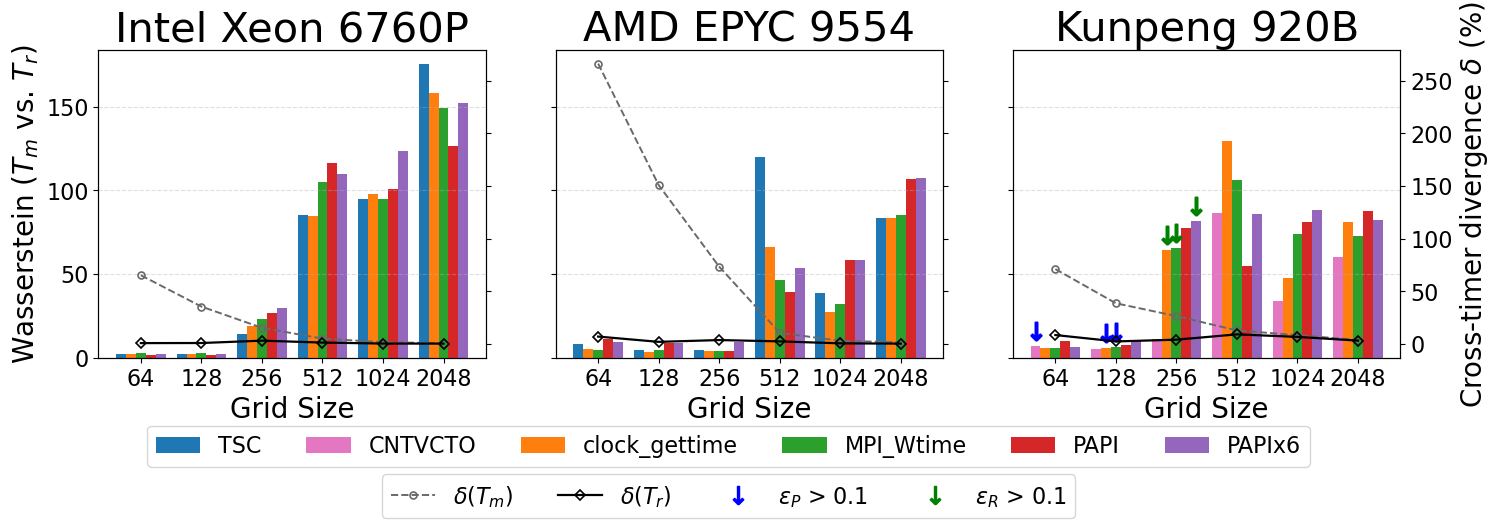

In [9]:
# Cross-timer divergence before (T_m) / after (T_r) + ep/er threshold indicators (stencil)
# Reuse div_size_df/div_df computed and printed in the previous cell.
from matplotlib.lines import Line2D

if 'div_size_df' not in globals() or div_size_df.empty:
    raise RuntimeError('div_size_df is missing or empty; run the size-level divergence cell before plotting')
div_df = div_size_df.copy()

# ---- thresholds (tune by hand) ----
EP_THRESHOLD = 0.1  # eps_P over this -> flag
ER_THRESHOLD = 0.1  # eps_R over this -> flag

# ---- fonts (tune by hand) ----
TITLE_FONTSIZE = 30
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16
ARROW_FONTSIZE = 13
# legend vertical offsets (more negative = lower); timer legend above, divergence legend below
TIMER_LEGEND_Y = 0.07
DIV_LEGEND_Y = -0.04


def _wd_seq(a, b):
    if a is None or b is None:
        return np.nan
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return wasserstein_distance(a, b) if (a.size and b.size) else np.nan


def divergence_table(src, group_keys):
    """Cross-timer divergence before (TM) and after (TR), plus deviation reduction ratio.
    delta = mean over non-ref timers of WD(timer, ref) / mean(ref measured time); same base
    for before/after so the two levels are comparable. reduction = (sum_tm - sum_tr)/sum_tm."""
    rows = []
    for gv, g in src.groupby(group_keys):
        gd = dict(zip(group_keys, gv if isinstance(gv, tuple) else (gv,)))
        ref_timer = REF_TIMER_BY_HOST.get(gd['host'])
        ref = g[g['timer'] == ref_timer]
        if ref.empty:
            continue
        ref = ref.iloc[0]
        ref_tm = np.asarray(ref['tm_seq'], dtype=float) if ref['tm_seq'] is not None else None
        base = float(np.mean(ref_tm)) if (ref_tm is not None and ref_tm.size) else np.nan
        tm_ds, tr_ds = [], []
        for _, r in g.iterrows():
            if r['timer'] == ref_timer:
                continue
            d_tm = _wd_seq(r['tm_seq'], ref['tm_seq'])
            d_tr = _wd_seq(r['tr_seq'], ref['tr_seq'])
            if np.isfinite(d_tm):
                tm_ds.append(d_tm)
            if np.isfinite(d_tr):
                tr_ds.append(d_tr)
        s_tm = float(np.sum(tm_ds)) if tm_ds else np.nan
        s_tr = float(np.sum(tr_ds)) if tr_ds else np.nan
        gd['reduction'] = (s_tm - s_tr) / s_tm if (np.isfinite(s_tm) and s_tm > 0) else np.nan
        if gd['reduction'] is np.nan:
            print(f"divergence_table group {gv}: base={base} sum_tm={s_tm} sum_tr={s_tr} reduction={gd['reduction']}")
        if int(gd['size']) == 256:
            print(f"divergence_table group {gv}: base={base} sum_tm={s_tm} sum_tr={s_tr} reduction={gd['reduction']}")

        if np.isfinite(base) and base > 0:
            gd['d_before'] = (np.mean(tm_ds) / base) if tm_ds else np.nan
            gd['d_after'] = (np.mean(tr_ds) / base) if tr_ds else np.nan
        else:
            gd['d_before'] = gd['d_after'] = np.nan
        rows.append(gd)
    return pd.DataFrame(rows)


def _flag_color(ep_v, er_v):
    ep_hi = np.isfinite(ep_v) and ep_v > EP_THRESHOLD
    er_hi = np.isfinite(er_v) and er_v > ER_THRESHOLD
    if ep_hi and er_hi:
        return 'red'
    if ep_hi:
        return 'blue'
    if er_hi:
        return 'green'
    return None


metric_bar = 'wd'

plot_df = df.copy()
plot_df['timer_label'] = plot_df['timer'].map(TIMER_LABELS).fillna(plot_df['timer'])
plot_df['kernel_label'] = plot_df['kernel'].map(KERNEL_LABELS).fillna(plot_df['kernel'])
plot_df['size_str'] = plot_df['size'].astype(str)
size_order = [str(x) for x in sorted(plot_df['size'].unique())]
plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]
kernels = sorted(plot_df['kernel'].dropna().unique())

for kernel in kernels:
    kernel_df = plot_df[plot_df['kernel'] == kernel].copy()
    if kernel_df.empty:
        continue
    dk = div_df[div_df['kernel'] == kernel]
    kernel_label = kernel_df['kernel_label'].iloc[0]
    refs = {HOST_LABELS.get(h, h): REF_TIMER_BY_HOST.get(h) for h in hosts}
    print(f'[WD / divergence Tm->Tr + eps]  kernel={kernel_label}  {SHUFFLE_LABEL}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}  ref_by_host={refs}')

    gmax = np.nanmax(kernel_df[metric_bar].to_numpy(dtype=float)) if len(kernel_df) else 1.0
    if not np.isfinite(gmax) or gmax <= 0:
        gmax = 1.0
    arrow_dy = 0.05 * gmax

    fig, axes = plt.subplots(1, len(hosts), figsize=(5.6 * len(hosts), 4.4), sharey=True, constrained_layout=False)
    if len(hosts) == 1:
        axes = [axes]

    right_axes = []
    bar_handles = {}          # keyed by timer -> handle, for ordered legend
    before_handle = after_handle = None
    any_red = False
    for ax1, host in zip(axes, hosts):
        host_df = kernel_df[kernel_df['host'] == host]
        ref_timer = REF_TIMER_BY_HOST.get(host)
        ax1.set_title(HOST_LABELS.get(host, host), fontsize=TITLE_FONTSIZE)
        ax1.set_xlabel('Grid Size', fontsize=AXIS_LABEL_FONTSIZE)
        ax1.set_ylabel(r'Wasserstein ($T_m$ vs. $T_r$)' if ax1 is axes[0] else '', fontsize=AXIS_LABEL_FONTSIZE)
        ax1.grid(axis='y', linestyle='--', alpha=0.4)

        ax2 = ax1.twinx()
        right_axes.append(ax2)

        if host_df.empty:
            ax1.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax1.transAxes)
            ax1.set_xticks([])
            ax2.set_yticks([])
            continue

        timers = sorted(host_df['timer'].unique(), key=timer_sort_key)
        x = np.arange(len(size_order))
        width = 0.82 / max(len(timers), 1)
        for i, timer in enumerate(timers):
            sub = host_df[host_df['timer'] == timer].set_index('size_str').reindex(size_order)
            offset = (i - (len(timers) - 1) / 2) * width
            heights = sub[metric_bar].to_numpy(dtype=float)
            b = ax1.bar(x + offset, heights, width=width, label=timer_label(timer), color=TIMER_COLORS.get(timer))
            bar_handles.setdefault(timer, b)
            ep_arr = sub['ep'].to_numpy(dtype=float)
            er_arr = sub['er'].to_numpy(dtype=float)
            for j in range(len(size_order)):
                h = heights[j]
                if not np.isfinite(h):
                    continue
                c = _flag_color(ep_arr[j], er_arr[j])
                if c is None:
                    continue
                if c == 'red':
                    any_red = True
                ax1.plot(x[j] + offset, h + arrow_dy, marker=r'$\downarrow$', linestyle='None',
                         color=c, markersize=ARROW_FONTSIZE, markeredgewidth=1.4, zorder=6, clip_on=False)

        # x ticks: horizontal, with the ref timer's (tsc/cntvct) TM p25/p75 on a second line
        xticklabels = []
        for s in size_order:
            rr = host_df[(host_df['timer'] == ref_timer) & (host_df['size'] == int(s))]
            if len(rr) and rr.iloc[0]['tm_seq'] is not None:
                seq = np.asarray(rr.iloc[0]['tm_seq'], dtype=float)
                p25, p75 = np.quantile(seq, 0.25), np.quantile(seq, 0.75)
                # xticklabels.append(f'{s}\n({p25:.0f}/{p75:.0f})')
                xticklabels.append(f'{s}')
            else:
                xticklabels.append(f'{s}')
        ax1.set_xticks(x)
        ax1.set_xticklabels(xticklabels, rotation=0, fontsize=TICK_FONTSIZE)
        ax1.tick_params(axis='y', labelsize=TICK_FONTSIZE)

        dh = dk[dk['host'] == host]
        db = dh.groupby('size')['d_before'].mean()
        da = dh.groupby('size')['d_after'].mean()
        before_vals = [100.0 * db.get(int(s), np.nan) for s in size_order]
        after_vals = [100.0 * da.get(int(s), np.nan) for s in size_order]
        lb, = ax2.plot(x, before_vals, marker='o', markersize=5, markerfacecolor='none', markeredgewidth=1.2, color='dimgray', linestyle='--', linewidth=1.4)
        la, = ax2.plot(x, after_vals, marker='D', markersize=5, markerfacecolor='none', markeredgewidth=1.2, color='black', linestyle='-', linewidth=1.6)

        print(f"kernel={kernel} h ost={host}  before: {before_vals}  after: {after_vals}")

        before_handle, after_handle = lb, la
        ax2.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    left_lims = [ax.get_ylim() for ax in axes]
    left_ylim = (min(lo for lo, hi in left_lims), max(hi for lo, hi in left_lims))
    for ax in axes:
        ax.set_ylim(left_ylim)
    rlims = [ax.get_ylim() for ax in right_axes]
    rylim = (min(lo for lo, hi in rlims), max(hi for lo, hi in rlims))
    for j, ax in enumerate(right_axes):
        ax.set_ylim(rylim)
        if j == len(right_axes) - 1:
            ax.set_ylabel(r'Cross-timer divergence $\delta$ (%)', fontsize=AXIS_LABEL_FONTSIZE)
        else:
            ax.set_yticklabels([])

    # timer legend (ordered by timer_sort_key), placed at the bottom
    ordered_timers = sorted(bar_handles, key=timer_sort_key)
    fig.legend([bar_handles[t] for t in ordered_timers], [timer_label(t) for t in ordered_timers],
               ncol=min(6, max(1, len(ordered_timers))), fontsize=LEGEND_FONTSIZE,
               loc='upper center', bbox_to_anchor=(0.5, TIMER_LEGEND_Y), frameon=True)

    # divergence legend (below the timer legend): delta lines + eps arrows (+both only if drawn)
    arrow_proxies = [
        Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='blue', markersize=ARROW_FONTSIZE, label=fr'$\epsilon_P$ > {EP_THRESHOLD:g}'),
        Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='green', markersize=ARROW_FONTSIZE, label=fr'$\epsilon_R$ > {ER_THRESHOLD:g}'),
    ]
    if any_red:
        arrow_proxies.append(Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='red', markersize=ARROW_FONTSIZE, label='both'))
    div_handles = [before_handle, after_handle] + arrow_proxies
    div_labels = [r'$\delta(T_m)$', r'$\delta(T_r)$'] + [p.get_label() for p in arrow_proxies]
    fig.legend(div_handles, div_labels, ncol=min(5, len(div_labels)), fontsize=LEGEND_FONTSIZE,
               loc='upper center', bbox_to_anchor=(0.5, DIV_LEGEND_Y), frameon=True)

    fig.subplots_adjust(bottom=0.20, top=0.90, wspace=0.18)

    if SAVE_FIG:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_wd_div_eper_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()

In [10]:
tmp_df = df.join(div_df, lsuffix="_left", rsuffix="_right",how='left').sort_values(['reduction'],ascending=False)[['host_left','size_left','kernel_left','ep','er','reduction']]
tmp_df[tmp_df['size_left'] == 256]

,host_left,size_left,kernel_left,ep,er,reduction
9,cgnr6760pn2,256,tl_f90_cg_calc_w,0.000000,0.035932,0.774619
15,cgnr6760pn2,256,tl_f90_cg_calc_w,0.000000,0.039636,0.753895
3,cgnr6760pn2,256,tl_f90_cg_calc_w,0.000000,0.032621,0.292370
63,c920bn3,256,tl_f90_cg_calc_w,0.000000,0.102069,NaN
69,c920bn3,256,tl_f90_cg_calc_w,0.000000,0.020009,NaN
75,c920bn3,256,tl_f90_cg_calc_w,0.000000,0.097237,NaN
81,c920bn3,256,tl_f90_cg_calc_w,0.000000,0.101686,NaN
87,c920bn3,256,tl_f90_cg_calc_w,0.000000,0.103809,NaN
33,camd9554n1,256,tl_f90_cg_calc_w,0.000000,0.009777,NaN
39,camd9554n1,256,tl_f90_cg_calc_w,0.000093,0.004247,NaN


In [11]:
# Per-kernel: grid sizes where ALL hosts' ALL timers satisfy ep <= EP_THRESHOLD and er <= ER_THRESHOLD.
print(f'Qualifying grid sizes (every host/timer has ep <= {EP_THRESHOLD:g} and er <= {ER_THRESHOLD:g}):')
for kernel in sorted(df['kernel'].dropna().unique()):
    kdf = df[df['kernel'] == kernel]
    good = []
    for size, sdf in kdf.groupby('size'):
        if (sdf['ep'] <= EP_THRESHOLD).all() and (sdf['er'] <= ER_THRESHOLD).all():
            good.append(int(size))
    print(f'  {KERNEL_LABELS.get(kernel, kernel)} ({kernel}): {sorted(good)}')

Qualifying grid sizes (every host/timer has ep <= 0.1 and er <= 0.1):
  TeaLeaf CG calc_w (tl_f90_cg_calc_w): [512, 1024, 2048]


# Filt Plot

In [12]:
entries['nsamp'].unique()

array([ 7236,   287, 16460,   607,  2002,   159,  7425,   475, 16636,
         792,  2178,   347,  7476,   478, 16659,  2205,   348,  7238,
         282, 16472,   602,   154,  7242,   291, 16464,   616,  2010,
         163, 16966,   325, 36666,   635,  5045,   172, 17868,  1257,
       37660,  1537,  6023,  1117, 17928, 37612,  1551,  6054, 16997,
         310, 36665,   620,  5028,   170, 16950, 36680,   621,  5042,
         184, 13441,   333, 30554,   913,  4175,   188, 12600,   318,
       29739,   811,  3798,   173, 13732,   536, 30858,  1159,  4451,
         391, 30697, 13484,   912])

[FILT CDF]  kernel=TeaLeaf CG calc_w  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=64  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=139.66 ns  tr_median=109.66 ns
host=cgnr6760pn2 timer=cgt  tm_median=144.76 ns  tr_median=108.76 ns
host=cgnr6760pn2 timer=wtime  tm_median=148.05 ns  tr_median=108.05 ns
host=cgnr6760pn2 timer=papi  tm_median=315.80 ns  tr_median=109.80 ns
host=cgnr6760pn2 timer=papix6  tm_median=316.81 ns  tr_median=109.81 ns
host=camd9554n1 timer=tsc  tm_median=115.44 ns  tr_median=104.87 ns
host=camd9554n1 timer=cgt  tm_median=118.08 ns  tr_median=97.27 ns
host=camd9554n1 timer=wtime  tm_median=123.44 ns  tr_median=102.32 ns
host=camd9554n1 timer=papi  tm_median=723.73 ns  tr_median=92.73 ns
host=camd9554n1 timer=papix6  tm_median=727.20 ns  tr_median=96.20 ns
host=c920bn3 timer=cntvcto  tm_median=120.00 ns  tr_median=100.00 ns
host=c920bn3 timer=cgt  tm_median=134.64 n

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_tl_f90_cg_calc_w_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size64_ratio0.5_tm_tr_by_host.png


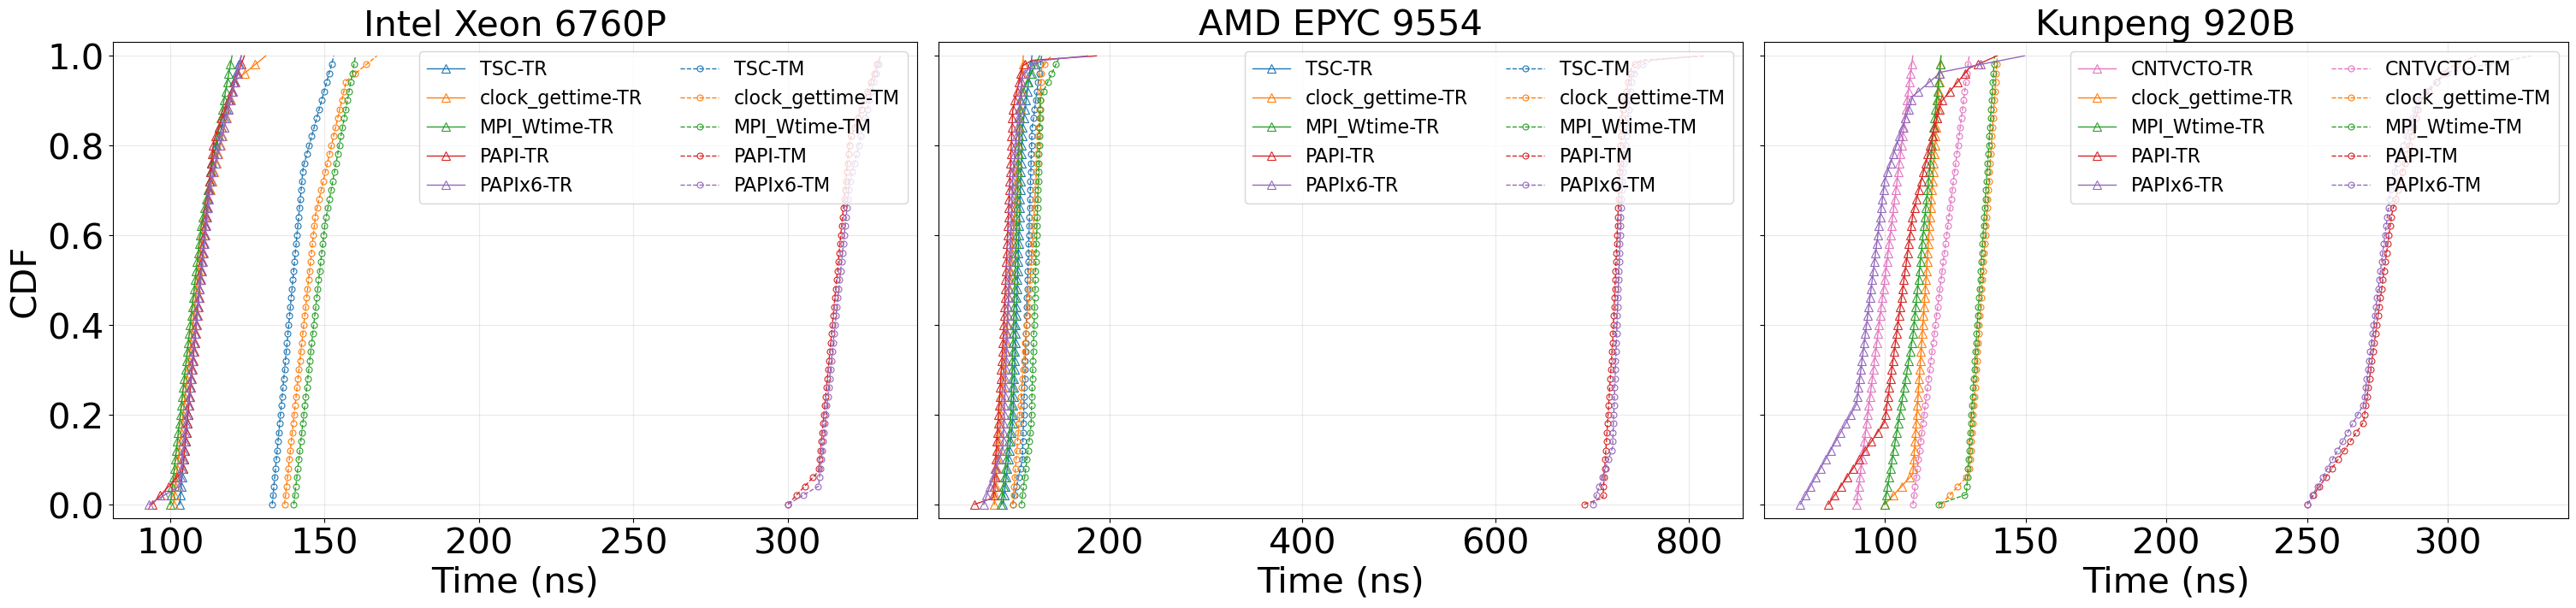

[FILT CDF]  kernel=TeaLeaf CG calc_w  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=128  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=256.79 ns  tr_median=226.79 ns
host=cgnr6760pn2 timer=cgt  tm_median=261.16 ns  tr_median=225.16 ns
host=cgnr6760pn2 timer=wtime  tm_median=265.56 ns  tr_median=224.56 ns
host=cgnr6760pn2 timer=papi  tm_median=431.84 ns  tr_median=224.84 ns
host=cgnr6760pn2 timer=papix6  tm_median=435.31 ns  tr_median=228.31 ns
host=camd9554n1 timer=tsc  tm_median=205.23 ns  tr_median=185.22 ns
host=camd9554n1 timer=cgt  tm_median=210.22 ns  tr_median=187.53 ns
host=camd9554n1 timer=wtime  tm_median=210.98 ns  tr_median=189.79 ns
host=camd9554n1 timer=papi  tm_median=814.30 ns  tr_median=182.30 ns
host=camd9554n1 timer=papix6  tm_median=816.67 ns  tr_median=185.67 ns
host=c920bn3 timer=cntvcto  tm_median=222.53 ns  tr_median=201.57 ns
host=c920bn3 timer=cgt  tm_median=236.

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_tl_f90_cg_calc_w_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size128_ratio0.5_tm_tr_by_host.png


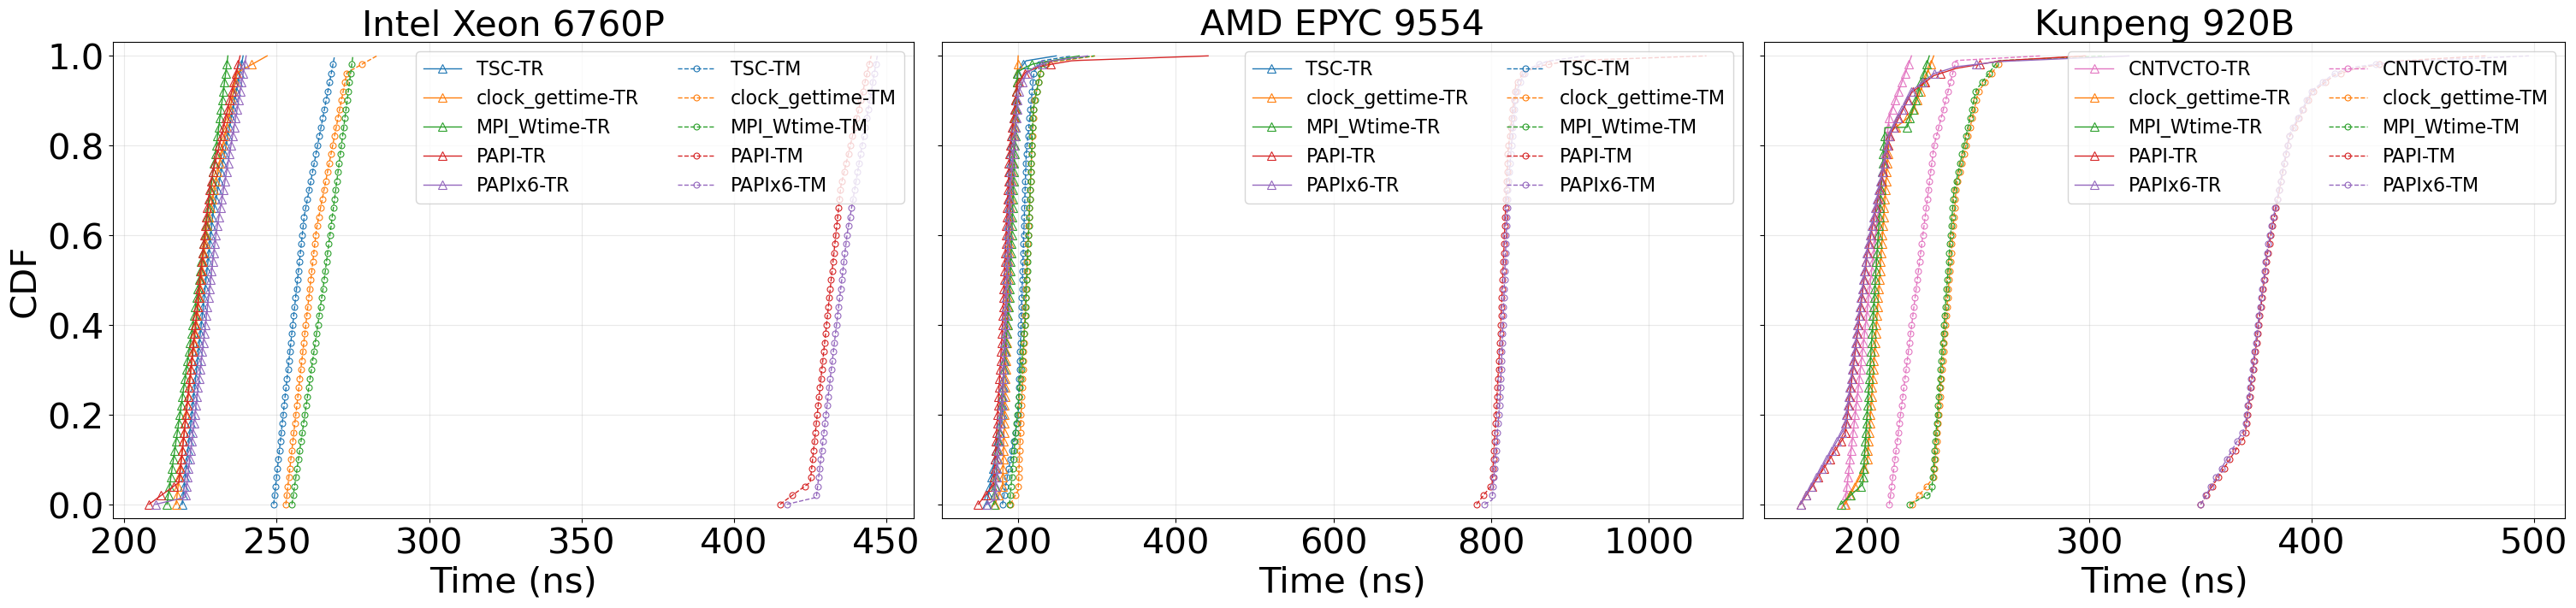

[FILT CDF]  kernel=TeaLeaf CG calc_w  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=256  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=548.15 ns  tr_median=513.97 ns
host=cgnr6760pn2 timer=cgt  tm_median=551.66 ns  tr_median=508.61 ns
host=cgnr6760pn2 timer=wtime  tm_median=559.94 ns  tr_median=508.42 ns
host=cgnr6760pn2 timer=papi  tm_median=720.53 ns  tr_median=500.51 ns
host=cgnr6760pn2 timer=papix6  tm_median=720.53 ns  tr_median=499.77 ns
host=camd9554n1 timer=tsc  tm_median=406.00 ns  tr_median=384.87 ns
host=camd9554n1 timer=cgt  tm_median=413.33 ns  tr_median=379.35 ns
host=camd9554n1 timer=wtime  tm_median=407.55 ns  tr_median=372.55 ns
host=camd9554n1 timer=papi  tm_median=998.35 ns  tr_median=358.35 ns
host=camd9554n1 timer=papix6  tm_median=1002.60 ns  tr_median=370.60 ns
host=c920bn3 timer=cntvcto  tm_median=563.52 ns  tr_median=520.79 ns
host=c920bn3 timer=cgt  tm_median=632

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_tl_f90_cg_calc_w_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size256_ratio0.5_tm_tr_by_host.png


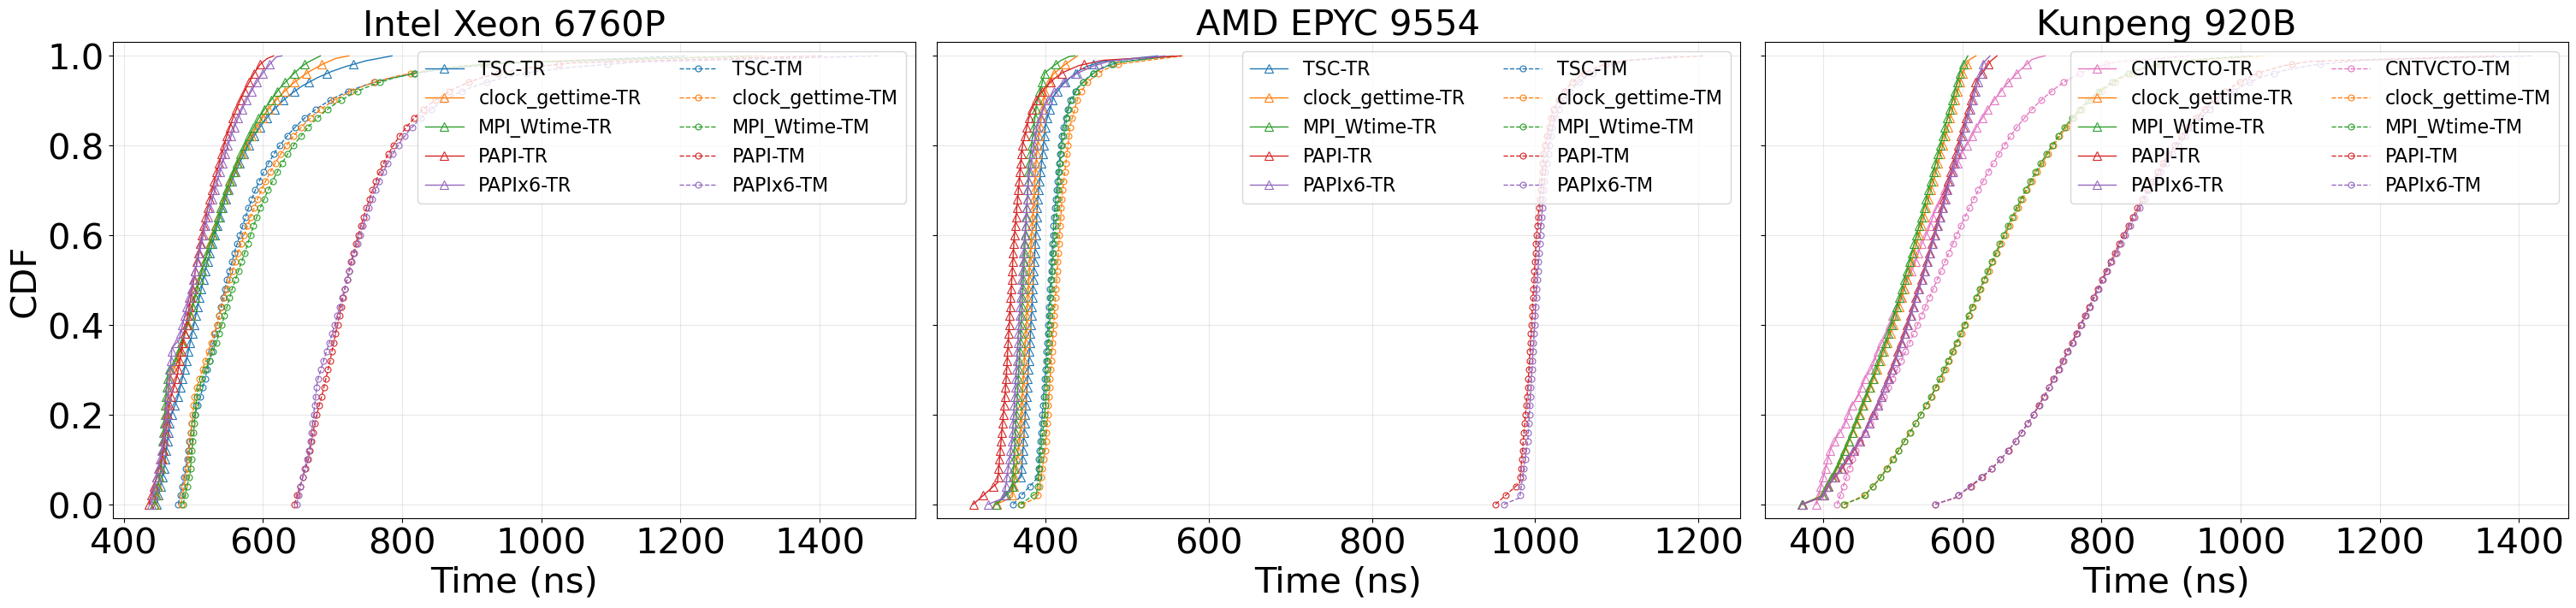

[FILT CDF]  kernel=TeaLeaf CG calc_w  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=512  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=1818.51 ns  tr_median=1740.47 ns
host=cgnr6760pn2 timer=cgt  tm_median=1818.97 ns  tr_median=1734.83 ns
host=cgnr6760pn2 timer=wtime  tm_median=1825.89 ns  tr_median=1723.94 ns
host=cgnr6760pn2 timer=papi  tm_median=1977.85 ns  tr_median=1696.61 ns
host=cgnr6760pn2 timer=papix6  tm_median=2003.18 ns  tr_median=1727.27 ns
host=camd9554n1 timer=tsc  tm_median=3241.47 ns  tr_median=3114.11 ns
host=camd9554n1 timer=cgt  tm_median=3249.40 ns  tr_median=3161.94 ns
host=camd9554n1 timer=wtime  tm_median=3246.77 ns  tr_median=3172.81 ns
host=camd9554n1 timer=papi  tm_median=3882.19 ns  tr_median=3200.79 ns
host=camd9554n1 timer=papix6  tm_median=3905.79 ns  tr_median=3213.90 ns
host=c920bn3 timer=cntvcto  tm_median=2625.63 ns  tr_median=2508.49 ns
host=c920bn3 tim

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_tl_f90_cg_calc_w_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size512_ratio0.5_tm_tr_by_host.png


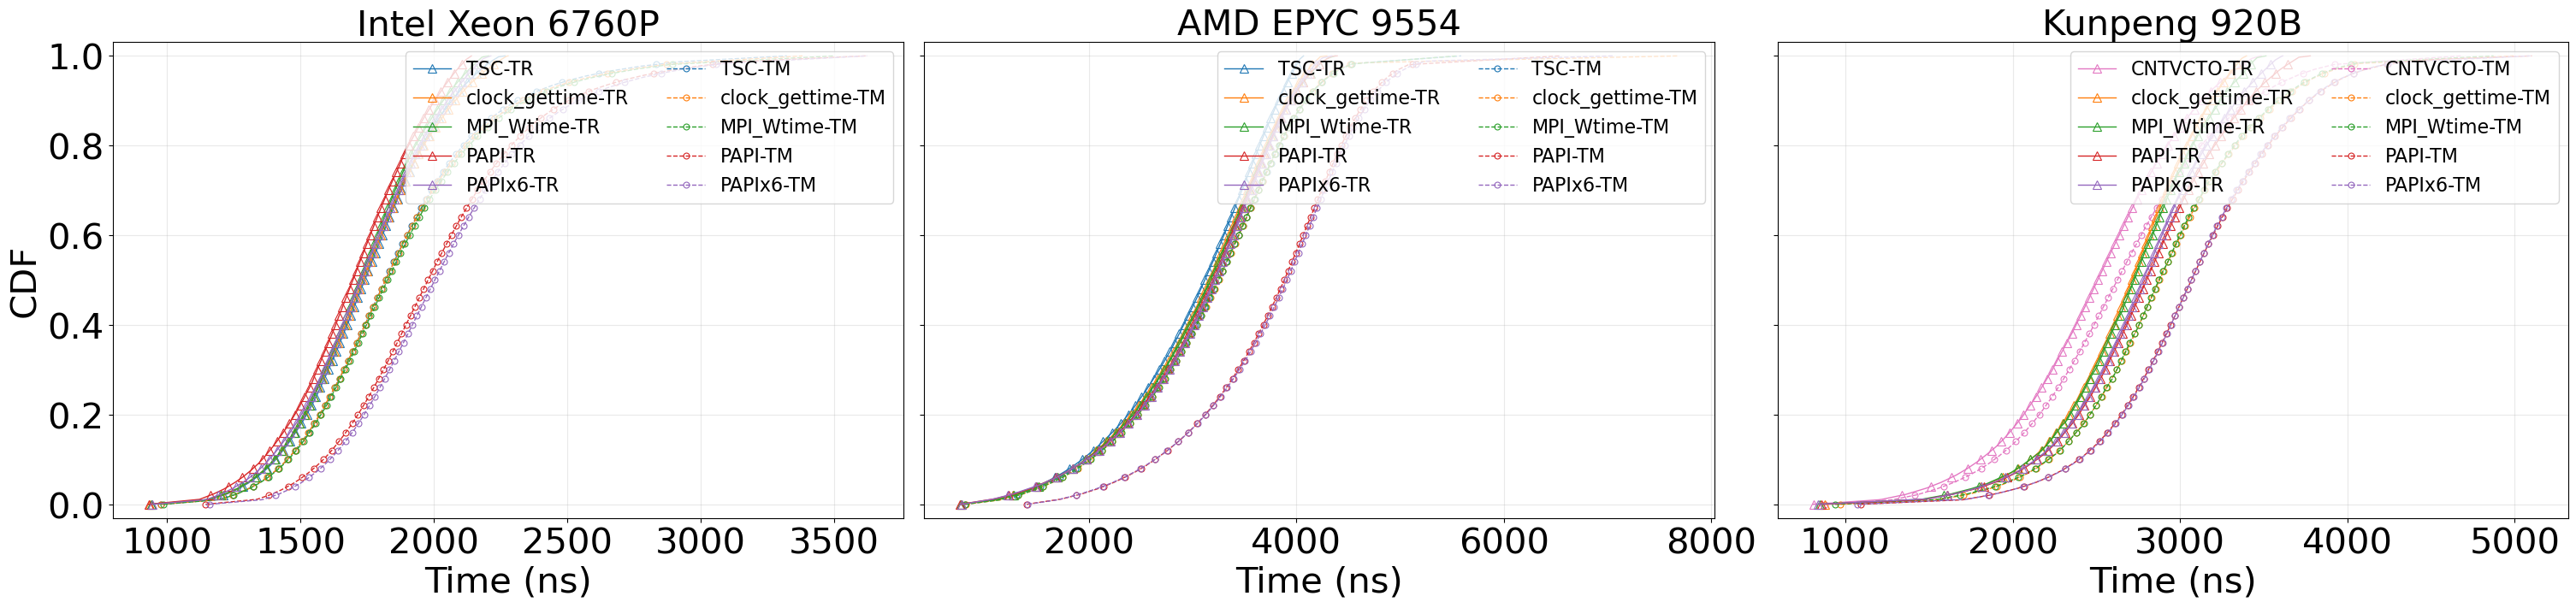

[FILT CDF]  kernel=TeaLeaf CG calc_w  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=1024  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=6577.23 ns  tr_median=6488.69 ns
host=cgnr6760pn2 timer=cgt  tm_median=6574.95 ns  tr_median=6479.08 ns
host=cgnr6760pn2 timer=wtime  tm_median=6580.74 ns  tr_median=6479.37 ns
host=cgnr6760pn2 timer=papi  tm_median=6745.78 ns  tr_median=6471.56 ns
host=cgnr6760pn2 timer=papix6  tm_median=6793.01 ns  tr_median=6510.62 ns
host=camd9554n1 timer=tsc  tm_median=10963.25 ns  tr_median=10909.67 ns
host=camd9554n1 timer=cgt  tm_median=10943.62 ns  tr_median=10883.45 ns
host=camd9554n1 timer=wtime  tm_median=10934.93 ns  tr_median=10870.34 ns
host=camd9554n1 timer=papi  tm_median=11530.96 ns  tr_median=10835.41 ns
host=camd9554n1 timer=papix6  tm_median=11566.41 ns  tr_median=10870.37 ns
host=c920bn3 timer=cntvcto  tm_median=8684.47 ns  tr_median=8476.44 ns
host=

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_tl_f90_cg_calc_w_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size1024_ratio0.5_tm_tr_by_host.png


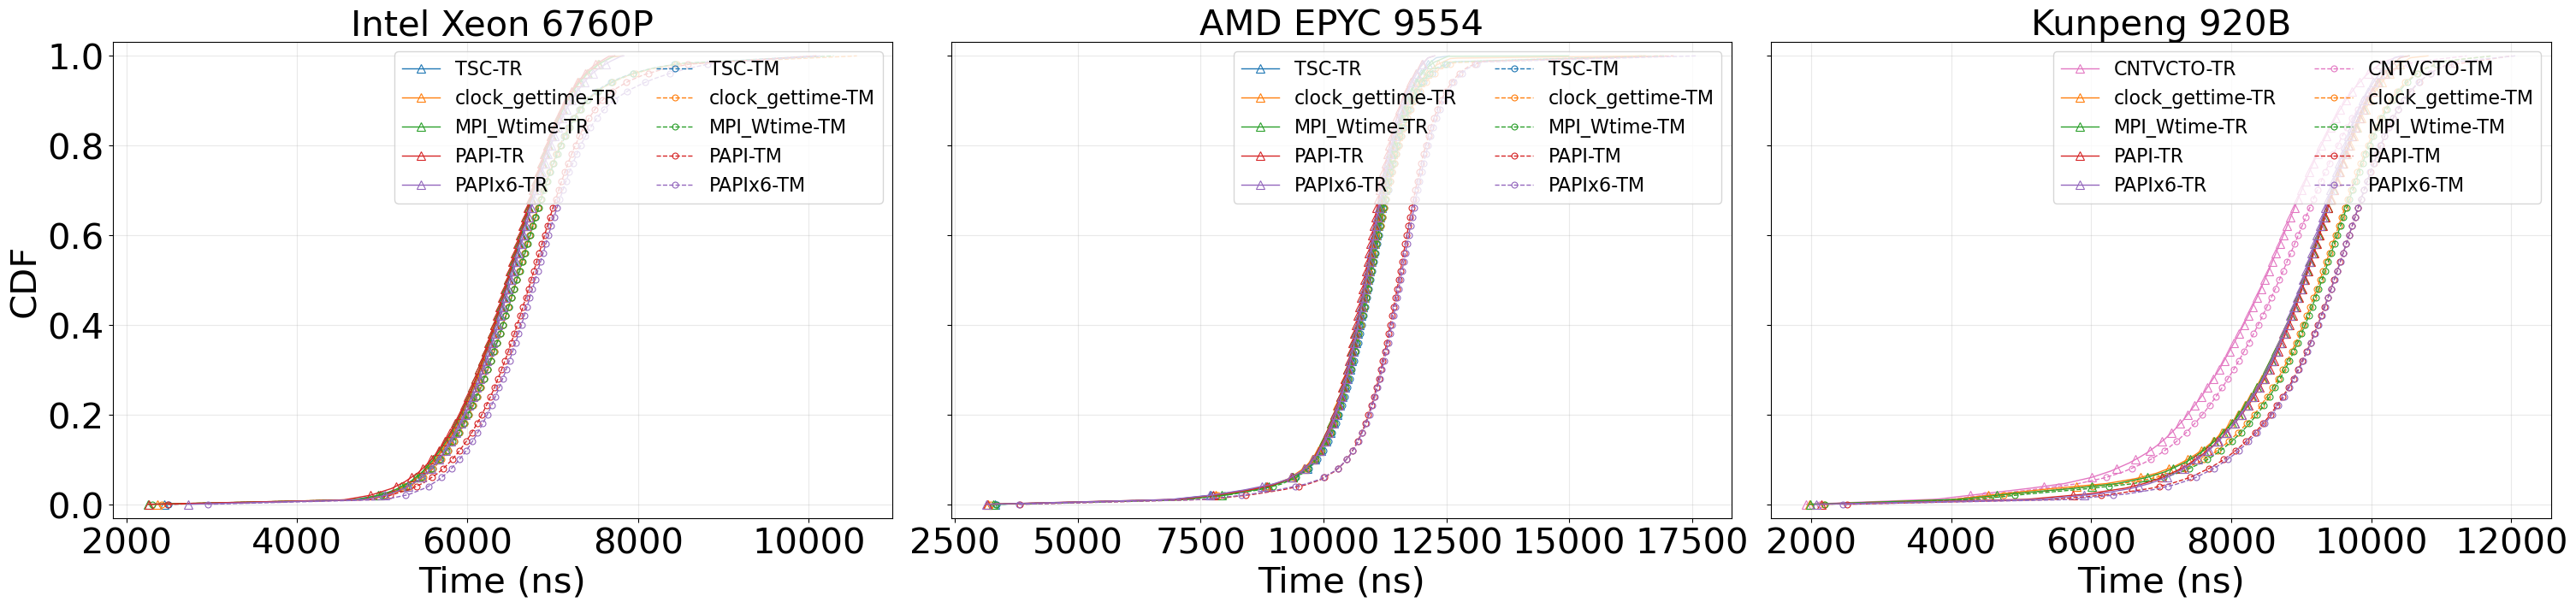

[FILT CDF]  kernel=TeaLeaf CG calc_w  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=2048  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=14969.27 ns  tr_median=14836.15 ns
host=cgnr6760pn2 timer=cgt  tm_median=14958.10 ns  tr_median=14821.83 ns
host=cgnr6760pn2 timer=wtime  tm_median=14962.38 ns  tr_median=14823.43 ns
host=cgnr6760pn2 timer=papi  tm_median=15117.51 ns  tr_median=14831.83 ns
host=cgnr6760pn2 timer=papix6  tm_median=15138.53 ns  tr_median=14837.52 ns
host=camd9554n1 timer=tsc  tm_median=23651.94 ns  tr_median=23559.92 ns
host=camd9554n1 timer=cgt  tm_median=23653.03 ns  tr_median=23558.64 ns
host=camd9554n1 timer=wtime  tm_median=23654.70 ns  tr_median=23558.77 ns
host=camd9554n1 timer=papi  tm_median=24293.22 ns  tr_median=23553.52 ns
host=camd9554n1 timer=papix6  tm_median=24251.59 ns  tr_median=23511.01 ns
host=c920bn3 timer=cntvcto  tm_median=20507.18 ns  tr_median=20098

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_tl_f90_cg_calc_w_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size2048_ratio0.5_tm_tr_by_host.png


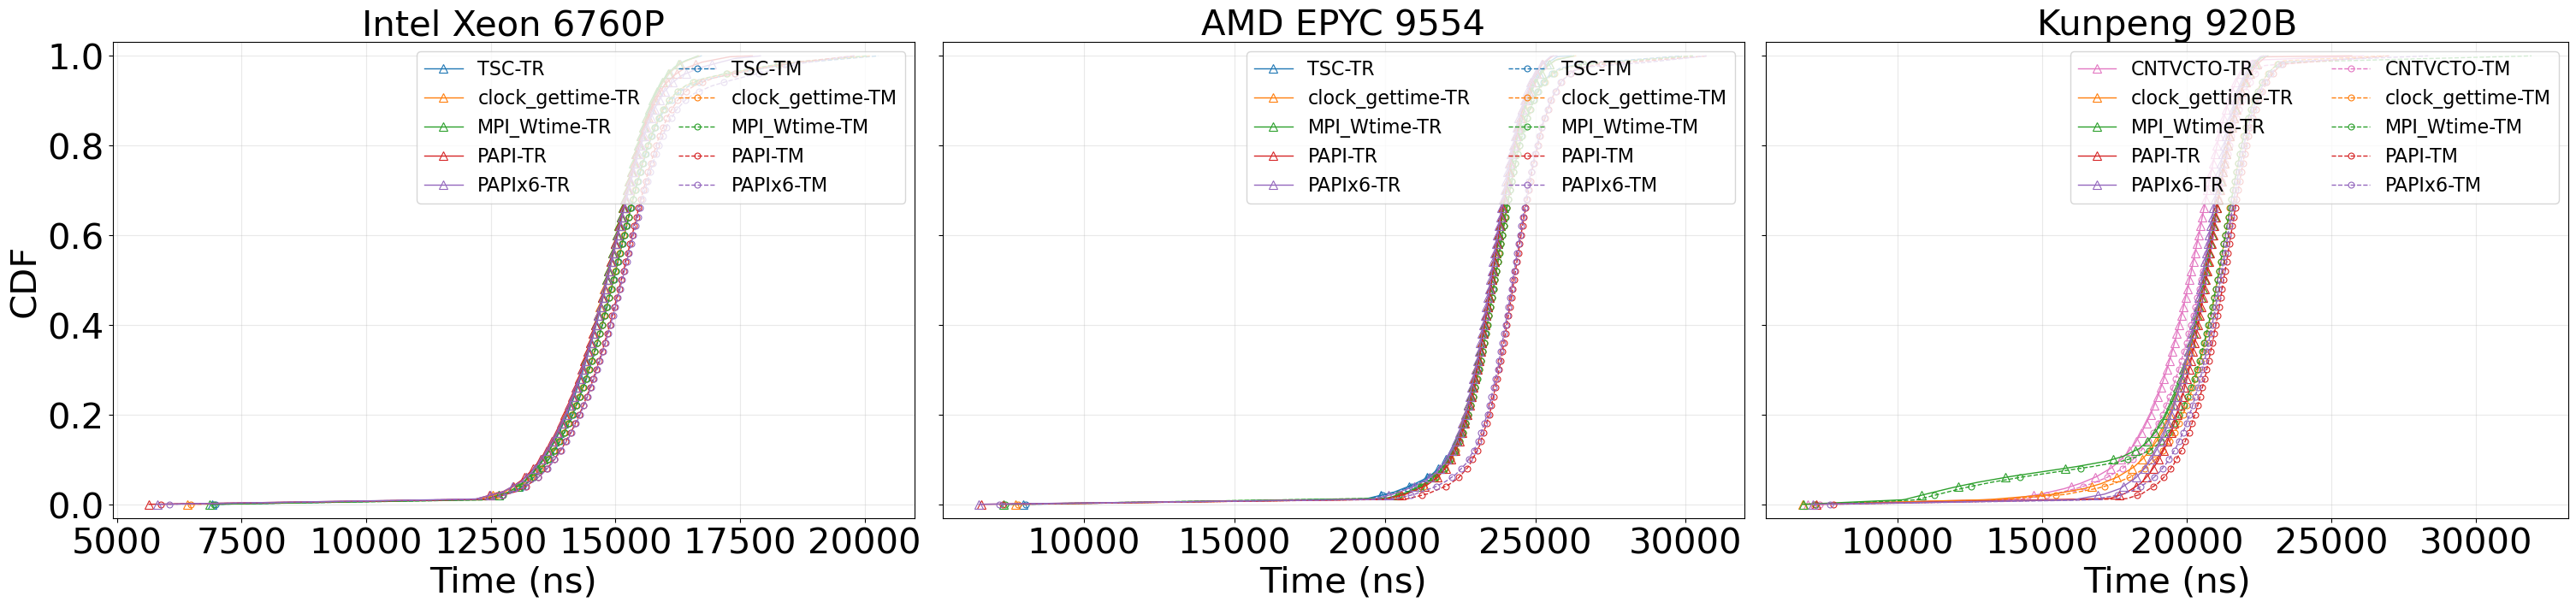

In [13]:
# ---- font sizes (tune here) ----
FILT_TITLE_FONTSIZE  = 30
FILT_LABEL_FONTSIZE  = 30
FILT_TICK_FONTSIZE   = 30
FILT_LEGEND_FONTSIZE = 16

plot_df = df[df['timer'] != 'likwid'].copy()

if plot_df.empty:
    raise RuntimeError('No entries with tr_seq/tm_seq to plot')

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]


def seq_ecdf(seq):
    """ECDF (x, y) from a sample array, clipped to QUANTILE_DROP."""
    s = np.sort(np.asarray(seq, dtype=float))
    n = s.size
    if n == 0:
        return s, s
    y = (np.arange(n) + 0.5) / n
    keep = y <= QUANTILE_DROP
    return s[keep], y[keep]


def _ordered_tr_tm(ax):
    """Legend handles ordered so each row pairs timer-TR, timer-TM (ncol=2, column-major)."""
    h, l = ax.get_legend_handles_labels()
    tr = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TR')]
    tm = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TM')]
    ordered = tr + tm
    return [hh for hh, ll in ordered], [ll for hh, ll in ordered]


for (kernel, np_val, size, nsamp_ratio), group_all in plot_df.groupby(['kernel', 'np', 'size', 'nsampRatio'], sort=True):
    print(f'[FILT CDF]  kernel={KERNEL_LABELS.get(kernel, kernel)}  {SHUFFLE_LABEL}  np={np_val}  size={size}  nsampRatio={nsamp_ratio}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}')
    fig, axes = plt.subplots(1, len(hosts), figsize=(10.0 * len(hosts), 7), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    for ax, host in zip(axes, hosts):
        group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))

        for _, row in group.iterrows():
            timer = row['timer']
            color = TIMER_COLORS.get(timer)
            label = timer_label(timer)

            if row['tm_seq'] is None or row['tr_seq'] is None:
                continue

            tm_x, tm_y = seq_ecdf(row['tm_seq'])
            tr_x, tr_y = seq_ecdf(row['tr_seq'])

            row['tm_median'] = np.median(row['tm_seq'])
            row['tr_median'] = np.median(row['tr_seq'])
            print(f"host={row['host']} timer={row['timer']}  tm_median={row['tm_median']:.2f} ns  tr_median={row['tr_median']:.2f} ns")

            tm_me = max(1, len(tm_x) // 50)
            tr_me = max(1, len(tr_x) // 50)

            ax.plot(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, marker='.', markevery=tm_me, markersize=10, markerfacecolor='none', markeredgewidth=0.8)
            ax.plot(tr_x, tr_y, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0, marker='^', markevery=tr_me, markersize=7, markerfacecolor='none', markeredgewidth=0.8)

        ax.set_title(f"{HOST_LABELS.get(host, host)}", fontsize=FILT_TITLE_FONTSIZE)
        ax.set_xlabel('Time (ns)', fontsize=FILT_LABEL_FONTSIZE)
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)
        ax.grid(True, alpha=0.28)
        ax.tick_params(axis='both', labelsize=FILT_TICK_FONTSIZE)
        oh, ol = _ordered_tr_tm(ax)
        if oh:
            ax.legend(oh, ol, ncol=2, fontsize=FILT_LEGEND_FONTSIZE, loc='upper right')

    for ax in axes:
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)

    axes[0].set_ylabel('CDF', fontsize=FILT_LABEL_FONTSIZE)

    if SAVE_FIG:
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_np{np_val}_size{size}_ratio{nsamp_ratio}_tm_tr_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()
